# Assignment 4 Student Notebook: Skin-Lesion Segmentation

Complete the TODO cells and run the required experiments.

Download the Dataset

In [ ]:
!pip install gdown
!gdown 1fOFVivt3jxjqjdvZtHme6Nqcw1MpWUI_

Downloading...
From (original): https://drive.google.com/uc?id=1fOFVivt3jxjqjdvZtHme6Nqcw1MpWUI_
From (redirected): https://drive.google.com/uc?id=1fOFVivt3jxjqjdvZtHme6Nqcw1MpWUI_&confirm=t&uuid=e2f621f6-27d2-4b3f-b5de-036fd117c194
To: /content/Dataset.zip
100% 2.38G/2.38G [00:17<00:00, 139MB/s]


In [ ]:
!unzip Dataset.zip
!rm Dataset/Images/LICENSE.txt

Archive:  Dataset.zip
   creating: Dataset/
   creating: Dataset/Images/
  inflating: Dataset/Images/ISIC_0012169.jpg  
  inflating: Dataset/Images/ISIC_0012236.jpg  
  inflating: Dataset/Images/ISIC_0012292.jpg  
  inflating: Dataset/Images/ISIC_0012302.jpg  
  inflating: Dataset/Images/ISIC_0012337.jpg  
  inflating: Dataset/Images/ISIC_0012373.jpg  
  inflating: Dataset/Images/ISIC_0012405.jpg  
  inflating: Dataset/Images/ISIC_0012418.jpg  
  inflating: Dataset/Images/ISIC_0012456.jpg  
  inflating: Dataset/Images/ISIC_0012472.jpg  
  inflating: Dataset/Images/ISIC_0012479.jpg  
  inflating: Dataset/Images/ISIC_0012558.jpg  
  inflating: Dataset/Images/ISIC_0012559.jpg  
  inflating: Dataset/Images/ISIC_0012560.jpg  
  inflating: Dataset/Images/ISIC_0012563.jpg  
  inflating: Dataset/Images/ISIC_0012564.jpg  
  inflating: Dataset/Images/ISIC_0012566.jpg  
  inflating: Dataset/Images/ISIC_0012572.jpg  
  inflating: Dataset/Images/ISIC_0012591.jpg  
  inflating: Dataset/Images/ISIC_0

## 1. Overview

This notebook trains the required segmentation models, reports the metrics, and saves prediction examples.

## 2. Imports

In [ ]:
# Standard imports
import os
import random
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [ ]:
TORCHVISION_AVAILABLE = True
try:
    from torchvision import transforms
    from torchvision.models import resnet50, ResNet50_Weights
except Exception as e:
    TORCHVISION_AVAILABLE = False
    print("torchvision is not available or failed to import.")
    print("The notebook will use fallback transforms and a fallback encoder.")
    print("Import error:", e)

## 3. Configuration

Edit the settings below as needed.

In [ ]:
@dataclass
class Config:
    dataset_dir: str = "./Dataset"
    image_dir: str = "Images"
    mask_dir: str = "Masks"
    image_size: int = 256
    batch_size: int = 16
    num_workers: int = 8  # set to 0 if running on CPU
    lr: float = 1e-4
    epochs: int = 10
    threshold: float = 0.5
    seed: int = 42
    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    output_dir: str = "./outputs"
    num_visualizations: int = 4

cfg = Config()
MODEL_VARIANTS = ["unet_scratch", "resunet_frozen", "resunet_finetune"]
LOSS_COMPARISON_MODEL = "resunet_finetune"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(cfg)

Device: cuda
Config(dataset_dir='./Dataset', image_dir='Images', mask_dir='Masks', image_size=256, batch_size=16, num_workers=8, lr=0.0001, epochs=10, threshold=0.5, seed=42, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, output_dir='./outputs', num_visualizations=4)


## 4. Reproducibility

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

## 5. Dataset paths

In [ ]:
if TORCHVISION_AVAILABLE:
    image_transform = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    mask_transform = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.PILToTensor(),
    ])
else:
    image_transform = None
    mask_transform = None

def simple_image_to_tensor(img: Image.Image) -> torch.Tensor:
    img = img.resize((cfg.image_size, cfg.image_size))
    arr = np.array(img).astype(np.float32) / 255.0
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    arr = arr.transpose(2, 0, 1)
    tensor = torch.from_numpy(arr)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = (tensor - mean) / std
    return tensor

def simple_mask_to_tensor(mask: Image.Image) -> torch.Tensor:
    mask = mask.resize((cfg.image_size, cfg.image_size))
    arr = np.array(mask)
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = (arr > 127).astype(np.float32)
    return torch.from_numpy(arr).unsqueeze(0)

## 6. Transforms

In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, file_names: List[str], image_root: Path, mask_root: Path):
        self.file_names = file_names
        self.image_root = image_root
        self.mask_root = mask_root

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        name = self.file_names[idx]
        image_path = self.image_root / f"{name}.jpg"
        mask_path = self.mask_root / f"{name}_segmentation.png"

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if TORCHVISION_AVAILABLE:
            image = image_transform(image)
            mask = mask_transform(mask).float() / 255.0
            mask = (mask > 0.5).float()
        else:
            image = simple_image_to_tensor(image)
            mask = simple_mask_to_tensor(mask)

        return image, mask, name

## 7. Dataset class

In [ ]:
def collect_file_names(dataset_dir: str, image_dir: str, mask_dir: str) -> Tuple[List[str], Path, Path]:
    image_root = Path(dataset_dir) / image_dir
    mask_root = Path(dataset_dir) / mask_dir

    if not image_root.exists():
        raise FileNotFoundError(f"Image folder not found: {image_root}")
    if not mask_root.exists():
        raise FileNotFoundError(f"Mask folder not found: {mask_root}")

    case_names = sorted([p.stem for p in image_root.iterdir() if p.is_file()])

    return case_names, image_root, mask_root

def split_file_names(file_names: List[str], seed: int, train_ratio: float, val_ratio: float, test_ratio: float):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1."

    rng = random.Random(seed)
    names = file_names.copy()
    rng.shuffle(names)

    n = len(names)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    train_names = names[:n_train]
    val_names = names[n_train:n_train+n_val]
    test_names = names[n_train+n_val:]

    return train_names, val_names, test_names

file_names, image_root, mask_root = collect_file_names(cfg.dataset_dir, cfg.image_dir, cfg.mask_dir)
train_names, val_names, test_names = split_file_names(
    file_names, cfg.seed, cfg.train_ratio, cfg.val_ratio, cfg.test_ratio
)

print("Total samples:", len(file_names))
print("Train:", len(train_names), "Val:", len(val_names), "Test:", len(test_names))

Total samples: 1000
Train: 700 Val: 150 Test: 150


## 8. Split and loaders

In [ ]:
train_dataset = SegmentationDataset(train_names, image_root, mask_root)
val_dataset = SegmentationDataset(val_names, image_root, mask_root)
test_dataset = SegmentationDataset(test_names, image_root, mask_root)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 9. Sample visualization

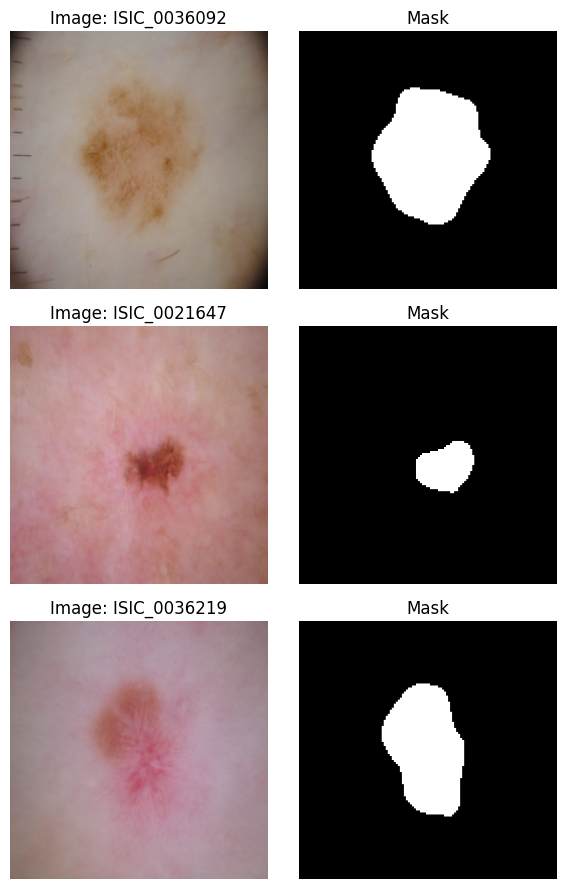

In [ ]:
def denormalize_image(x: torch.Tensor) -> np.ndarray:
    x = x.detach().cpu().clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    x = x * std + mean
    x = x.clamp(0, 1)
    return x.permute(1, 2, 0).numpy()

def show_dataset_samples(dataset, n=3):
    fig, axes = plt.subplots(n, 2, figsize=(6, 3*n))
    if n == 1:
        axes = np.array([axes])

    for i in range(n):
        image, mask, name = dataset[i]
        axes[i, 0].imshow(denormalize_image(image))
        axes[i, 0].set_title(f"Image: {name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask.squeeze().numpy(), cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

show_dataset_samples(train_dataset, n=min(3, len(train_dataset)))

## 10. Metrics

Complete the metric functions for binary segmentation.

In [ ]:
def confusion_matrix_from_masks(y_true: torch.Tensor, y_pred: torch.Tensor):
    # TODO:
    # 1. Flatten the tensors.
    # 2. Count TN, FP, FN, TP.
    # 3. Return them in the order: tn, fp, fn, tp.
    raise NotImplementedError("TODO: confusion matrix")


def calculate_metrics(y_true: torch.Tensor, y_pred: torch.Tensor):
    # TODO:
    # Use the confusion counts to compute:
    # ACC, Dice, IoU, FPR, FNR
    raise NotImplementedError("TODO: metrics")

## 11. Losses

Complete Dice loss and Dice+BCE loss.

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        # TODO:
        # 1. Convert logits to probabilities with sigmoid.
        # 2. Flatten predictions and targets.
        # 3. Compute Dice loss.
        raise NotImplementedError("TODO: Dice loss")


class DiceBCELoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.dice = DiceLoss(smooth=smooth)
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        # TODO:
        # Return Dice loss + BCE loss.
        raise NotImplementedError("TODO: Dice + BCE loss")


def build_criterion(loss_name: str):
    # TODO:
    # Return DiceLoss() for "dice"
    # Return DiceBCELoss() for "dice_bce"
    raise NotImplementedError("TODO: build criterion")

## 12. Decoder blocks

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_channels // 2 + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

## 13. U-Net

Complete the baseline model.

In [ ]:
class UNetScratch(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = ConvBlock(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(512, 1024)

        self.dec4 = DecoderBlock(1024, 512, 512)
        self.dec3 = DecoderBlock(512, 256, 256)
        self.dec2 = DecoderBlock(256, 128, 128)
        self.dec1 = DecoderBlock(128, 64, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # TODO:
        # Run the encoder, bottleneck, decoder, and final output layer.
        raise NotImplementedError("TODO: U-Net forward")

## 14. Encoder

In [ ]:
class FallbackEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer0 = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.MaxPool2d(2)
        self.layer1 = ConvBlock(64, 128)
        self.layer2 = ConvBlock(128, 256)
        self.layer3 = ConvBlock(256, 512)
        self.layer4 = ConvBlock(512, 1024)

    def forward(self, x):
        x0 = self.layer0(x)                   # 1/2
        x1 = self.layer1(self.pool(x0))       # 1/4
        x2 = self.layer2(F.max_pool2d(x1, 2)) # 1/8
        x3 = self.layer3(F.max_pool2d(x2, 2)) # 1/16
        x4 = self.layer4(F.max_pool2d(x3, 2)) # 1/32
        return x0, x1, x2, x3, x4

class ResNetEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.using_torchvision = TORCHVISION_AVAILABLE
        if TORCHVISION_AVAILABLE:
            weights = ResNet50_Weights.DEFAULT if pretrained else None
            backbone = resnet50(weights=weights)
            self.layer0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)   # 1/2
            self.pool = backbone.maxpool                                               # 1/4 after pooling
            self.layer1 = backbone.layer1
            self.layer2 = backbone.layer2
            self.layer3 = backbone.layer3
            self.layer4 = backbone.layer4
        else:
            self.fallback = FallbackEncoder()

    def forward(self, x):
        if self.using_torchvision:
            x0 = self.layer0(x)          # 64 channels
            x1 = self.layer1(self.pool(x0))
            x2 = self.layer2(x1)
            x3 = self.layer3(x2)
            x4 = self.layer4(x3)
            return x0, x1, x2, x3, x4
        else:
            return self.fallback(x)

## 15. ResUNet

Complete the pretrained model.

In [ ]:
class ResUNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.encoder = ResNetEncoder(pretrained=pretrained)

        if TORCHVISION_AVAILABLE:
            ch0, ch1, ch2, ch3, ch4 = 64, 256, 512, 1024, 2048
        else:
            ch0, ch1, ch2, ch3, ch4 = 64, 128, 256, 512, 1024

        self.center = ConvBlock(ch4, ch4)

        self.dec4 = DecoderBlock(ch4, ch3, 512)
        self.dec3 = DecoderBlock(512, ch2, 256)
        self.dec2 = DecoderBlock(256, ch1, 128)
        self.dec1 = DecoderBlock(128, ch0, 64)

        self.out_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # TODO:
        # 1. Get encoder feature maps.
        # 2. Run the center block and decoder blocks.
        # 3. Produce the final 1-channel logit map.
        # 4. Resize to the input spatial size if needed.
        raise NotImplementedError("TODO: ResUNet forward")

## 16. Model factory

Build the required model variants.

In [ ]:
def freeze_batchnorm(module: nn.Module):
    # You may keep this helper as given.
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            for p in m.parameters():
                p.requires_grad = False


def build_model(model_name: str):
    # TODO:
    # - "unet_scratch": build U-Net from scratch
    # - "resunet_frozen": build ResUNet and freeze the encoder
    # - "resunet_finetune": build ResUNet and train all layers
    raise NotImplementedError("TODO: build model")

## 17. Train and evaluate

Complete the training and evaluation loops.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    # TODO:
    # Run one training epoch and return the average training loss.
    raise NotImplementedError("TODO: train one epoch")


@torch.no_grad()
def evaluate(model, loader, criterion, threshold=0.5):
    # TODO:
    # Evaluate the model and return:
    # average loss, average metrics dictionary
    raise NotImplementedError("TODO: evaluate")

## 18. Train one experiment

Train one model-loss experiment and return the test metrics.

In [ ]:
def train_model(model_name: str, loss_name: str, cfg: Config):
    # TODO:
    # 1. Build the model and loss.
    # 2. Create the optimizer.
    # 3. Train for cfg.epochs.
    # 4. Save the best checkpoint using validation Dice.
    # 5. Evaluate on the test set.
    # 6. Return model, history_df, metrics_row.
    raise NotImplementedError("TODO: train one experiment")

## 19. Save predictions

In [ ]:
@torch.no_grad()
def save_predictions(model, loader, save_dir: str, threshold: float = 0.5, max_items: int = 4):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    model.eval()
    saved = 0

    for images, masks, names in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        for i in range(images.size(0)):
            if saved >= max_items:
                return

            image_np = denormalize_image(images[i].cpu())
            mask_np = masks[i].squeeze().cpu().numpy()
            pred_np = preds[i].squeeze().cpu().numpy()

            fig, axes = plt.subplots(1, 3, figsize=(9, 3))
            axes[0].imshow(image_np)
            axes[0].set_title("Image")
            axes[0].axis("off")

            axes[1].imshow(mask_np, cmap="gray")
            axes[1].set_title("Ground Truth")
            axes[1].axis("off")

            axes[2].imshow(pred_np, cmap="gray")
            axes[2].set_title("Prediction")
            axes[2].axis("off")

            plt.tight_layout()
            out_path = save_dir / f"{Path(names[i]).stem}_comparison.png"
            plt.savefig(out_path, bbox_inches="tight")
            plt.close(fig)

            saved += 1

## 20. Run assignment experiments

Run the required experiments for Table 1 and Table 2.

In [ ]:
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)

# TODO:
# Run these experiments:
# 1. unet_scratch + dice
# 2. resunet_frozen + dice
# 3. resunet_finetune + dice
# 4. resunet_finetune + dice_bce
#
# Suggested outputs:
# - all_results
# - all_histories
# - trained_models
# - loss_results
# - loss_histories
raise NotImplementedError("TODO: run assignment experiments")


===== Training unet_scratch =====


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 01/10 | Train Loss: 0.5076 | Val Loss: 0.4077 | Val Dice: 0.7139
Epoch 02/10 | Train Loss: 0.4137 | Val Loss: 0.3948 | Val Dice: 0.7367
Epoch 03/10 | Train Loss: 0.3807 | Val Loss: 0.3748 | Val Dice: 0.7502
Epoch 04/10 | Train Loss: 0.3613 | Val Loss: 0.3735 | Val Dice: 0.7440
Epoch 05/10 | Train Loss: 0.3425 | Val Loss: 0.3622 | Val Dice: 0.7846
Epoch 06/10 | Train Loss: 0.3180 | Val Loss: 0.3243 | Val Dice: 0.8011
Epoch 07/10 | Train Loss: 0.3063 | Val Loss: 0.3282 | Val Dice: 0.7925
Epoch 08/10 | Train Loss: 0.2927 | Val Loss: 0.2919 | Val Dice: 0.8263
Epoch 09/10 | Train Loss: 0.2753 | Val Loss: 0.2996 | Val Dice: 0.8113
Epoch 10/10 | Train Loss: 0.2626 | Val Loss: 0.2914 | Val Dice: 0.8101
Best validation Dice: 0.8263
Test metrics: {'Model': 'unet_scratch', 'TestLoss': 0.28160349527994794, 'ACC': 0.9185637410481771, 'Dice': 0.839303840565373, 'IoU': 0.7557194252165685, 'FPR': 0.05015516998031347, 'FNR': 0.09777985221571729}

===== Training resunet_frozen =====
Downloading: "

100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


Epoch 01/10 | Train Loss: 0.4990 | Val Loss: 0.4458 | Val Dice: 0.6706
Epoch 02/10 | Train Loss: 0.3780 | Val Loss: 0.4122 | Val Dice: 0.7013
Epoch 03/10 | Train Loss: 0.3432 | Val Loss: 0.3758 | Val Dice: 0.8276
Epoch 04/10 | Train Loss: 0.3193 | Val Loss: 0.3607 | Val Dice: 0.7759
Epoch 05/10 | Train Loss: 0.2992 | Val Loss: 0.3071 | Val Dice: 0.8130
Epoch 06/10 | Train Loss: 0.2798 | Val Loss: 0.3038 | Val Dice: 0.8518
Epoch 07/10 | Train Loss: 0.2614 | Val Loss: 0.3070 | Val Dice: 0.8129
Epoch 08/10 | Train Loss: 0.2437 | Val Loss: 0.2972 | Val Dice: 0.8134
Epoch 09/10 | Train Loss: 0.2319 | Val Loss: 0.2484 | Val Dice: 0.8492
Epoch 10/10 | Train Loss: 0.2170 | Val Loss: 0.2701 | Val Dice: 0.8286
Best validation Dice: 0.8518
Test metrics: {'Model': 'resunet_frozen', 'TestLoss': 0.2994022496541341, 'ACC': 0.9266742960611979, 'Dice': 0.8515410949730445, 'IoU': 0.7736719954435239, 'FPR': 0.07241407566388314, 'FNR': 0.08570705093078011}

===== Training resunet_finetune =====
Epoch 01/1

## 21. Table 1: model comparison

In [ ]:
model_results_df = pd.DataFrame(all_results)
table1_df = model_results_df[["Model", "ACC", "Dice", "IoU", "FPR", "FNR", "TestLoss"]]
table1_df

,Model,ACC,Dice,IoU,FPR,FNR,TestLoss
0,unet_scratch,0.918564,0.839304,0.755719,0.050155,0.097780,0.281603
1,resunet_frozen,0.926674,0.851541,0.773672,0.072414,0.085707,0.299402
2,resunet_finetune,0.939419,0.886991,0.822288,0.042537,0.106547,0.184570


## 22. Save tables

This saves both required result tables.

In [ ]:
loss_results_df = pd.DataFrame(loss_results)
table2_df = loss_results_df[["Loss", "ACC", "Dice", "IoU", "FPR", "FNR", "TestLoss"]]
display(table2_df)

table1_path = Path(cfg.output_dir) / "table1_model_comparison.csv"
table2_path = Path(cfg.output_dir) / "table2_loss_comparison.csv"

table1_df.to_csv(table1_path, index=False)
table2_df.to_csv(table2_path, index=False)

print("Saved:", table1_path)
print("Saved:", table2_path)

Saved results to: outputs/final_results.csv


## 23. Plot curves

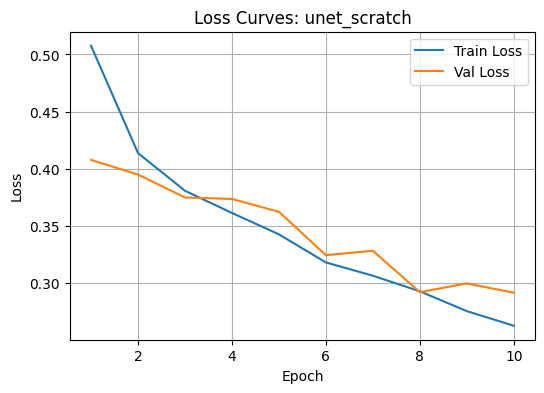

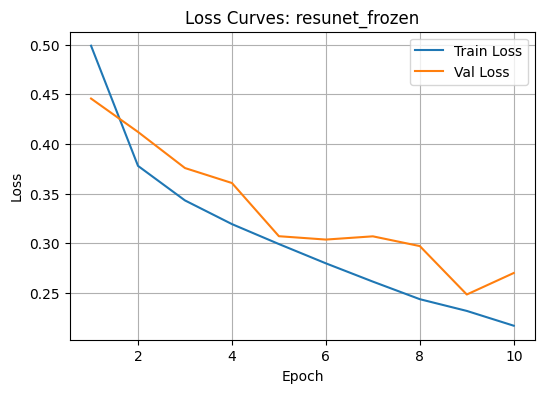

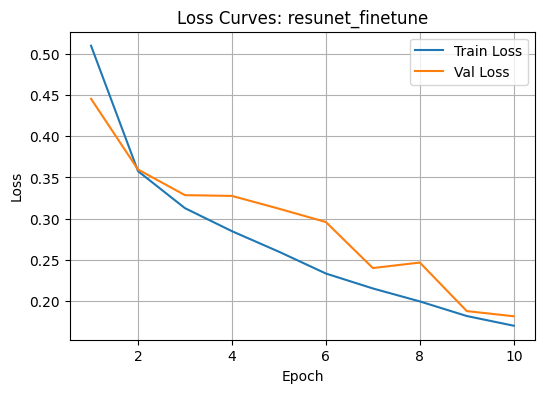

In [ ]:
def plot_histories(history_dict):
    for name, df in history_dict.items():
        plt.figure(figsize=(6, 4))
        plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
        plt.plot(df["epoch"], df["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(name)
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_histories(all_histories)
plot_histories(loss_histories)

## 24. Show saved prediction examples

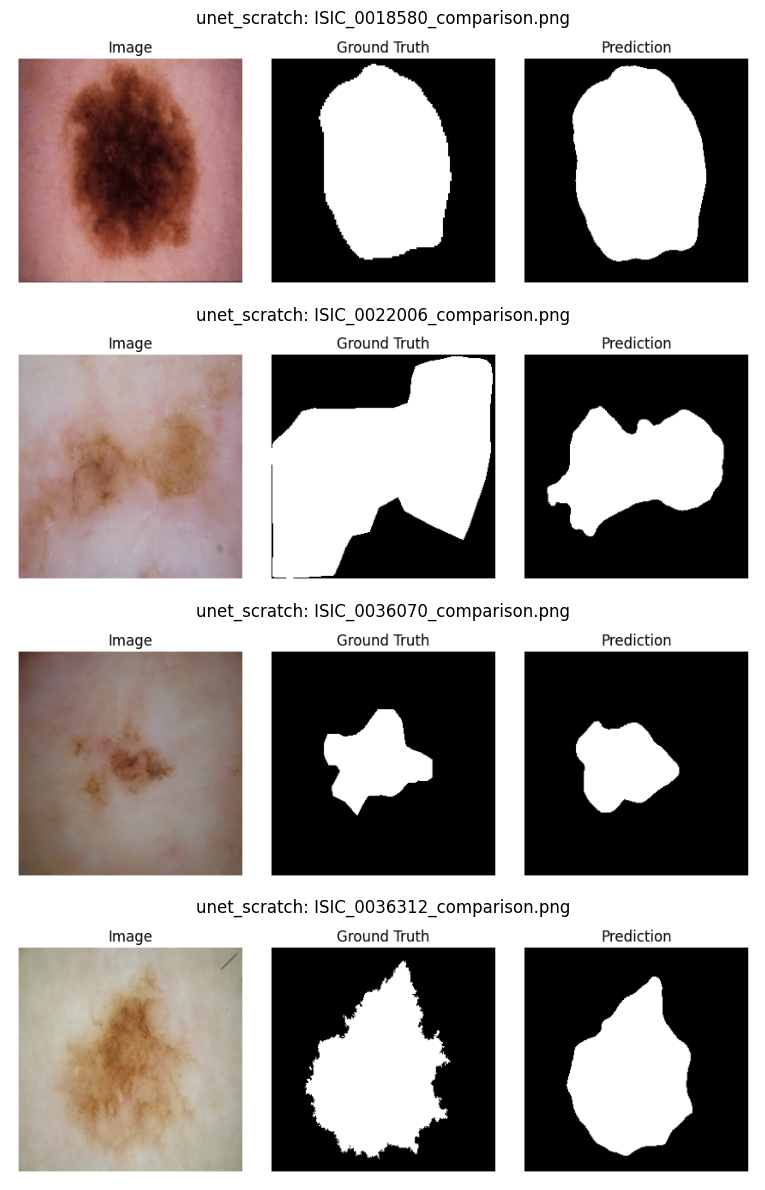

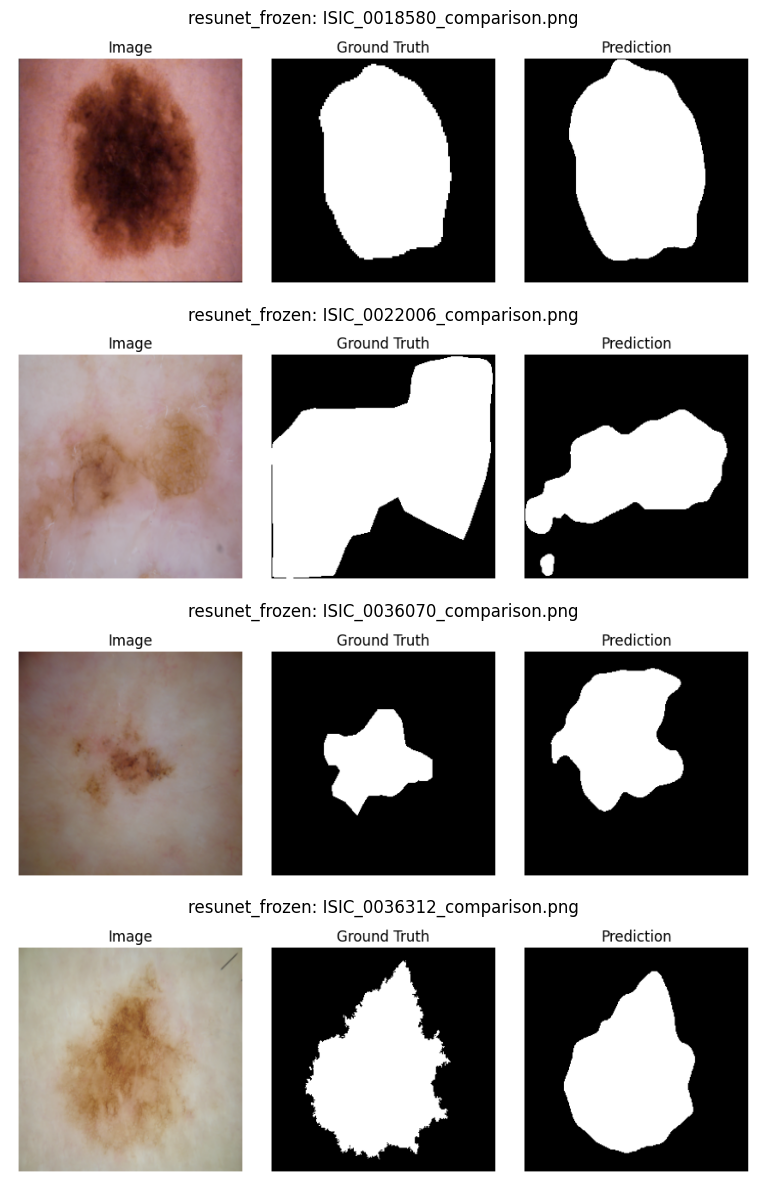

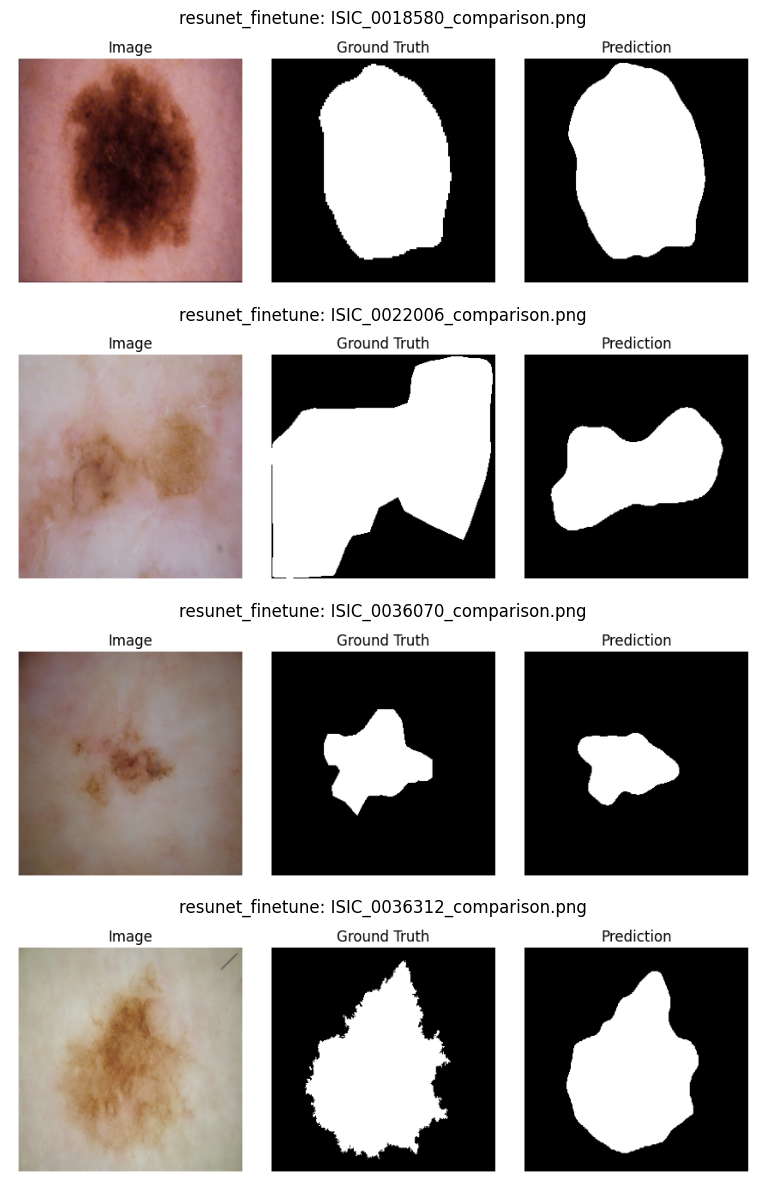

In [ ]:
def show_saved_predictions(output_dir: str, experiment_name: str, max_items: int = 4):
    pred_dir = Path(output_dir) / experiment_name / "predictions"
    files = sorted(pred_dir.glob("*.png"))[:max_items]
    if not files:
        print("No saved predictions found for", experiment_name)
        return

    plt.figure(figsize=(10, 3 * len(files)))
    for i, file_path in enumerate(files, start=1):
        img = Image.open(file_path)
        plt.subplot(len(files), 1, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(file_path.name)
    plt.tight_layout()
    plt.show()

for experiment_name in ["unet_scratch_dice", "resunet_frozen_dice", "resunet_finetune_dice"]:
    show_saved_predictions(cfg.output_dir, experiment_name, max_items=cfg.num_visualizations)

## 25. Notes

Keep your notebook output organized and report the settings you used.

## 26. Saved outputs

Save the required tables and prediction figures.